In [273]:
import pandas as pd,numpy as np,seaborn as sns

In [274]:
from pydataset import data

In [275]:
iris=data('iris')

In [276]:
iris.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa


In [277]:
pd.value_counts(iris['Species'])

setosa        50
versicolor    50
virginica     50
Name: Species, dtype: int64

# data preprocessing
# label encoding of species column 

In [278]:
from sklearn.preprocessing import LabelEncoder

In [279]:
encode=LabelEncoder()

In [280]:
iris['Species']=encode.fit_transform(iris['Species'])

In [281]:
iris.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
1,5.1,3.5,1.4,0.2,0
2,4.9,3.0,1.4,0.2,0
3,4.7,3.2,1.3,0.2,0
4,4.6,3.1,1.5,0.2,0
5,5.0,3.6,1.4,0.2,0


In [282]:

iris.head(60)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
1,5.1,3.5,1.4,0.2,0
2,4.9,3.0,1.4,0.2,0
3,4.7,3.2,1.3,0.2,0
4,4.6,3.1,1.5,0.2,0
5,5.0,3.6,1.4,0.2,0
6,5.4,3.9,1.7,0.4,0
7,4.6,3.4,1.4,0.3,0
8,5.0,3.4,1.5,0.2,0
9,4.4,2.9,1.4,0.2,0
10,4.9,3.1,1.5,0.1,0


In [283]:
#checking null values
pd.isna(iris).sum()

Sepal.Length    0
Sepal.Width     0
Petal.Length    0
Petal.Width     0
Species         0
dtype: int64

In [284]:
# checking duplicates
iris.duplicated().sum()

1

In [285]:
#dropping duplicated row
iris.drop_duplicates()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
1,5.1,3.5,1.4,0.2,0
2,4.9,3.0,1.4,0.2,0
3,4.7,3.2,1.3,0.2,0
4,4.6,3.1,1.5,0.2,0
5,5.0,3.6,1.4,0.2,0
6,5.4,3.9,1.7,0.4,0
7,4.6,3.4,1.4,0.3,0
8,5.0,3.4,1.5,0.2,0
9,4.4,2.9,1.4,0.2,0
10,4.9,3.1,1.5,0.1,0


In [286]:
iris=iris.drop_duplicates()



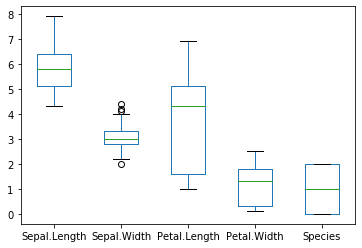

In [287]:
# check for the outliers
iris.plot(kind="box")

# we observe  there are ouliers in sepal width


# we shall cap the outliers

In [288]:
iris.describe()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
count,149.000000,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631,0.993289
std,0.830851,0.436342,1.767791,0.762622,0.817847
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.300000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# we observe that sepal.width min=2,max=4.4
# the values below 2 we should bring them to 2 and the values above 4.4 we should bring them to 4.4


# capping the values 

In [289]:
# the values below 2 replace with 2 otherwise remain same
iris['Sepal.Width']=np.where(iris['Sepal.Width']<2,2,iris['Sepal.Width'])

In [290]:
#the values above 4.4 should be replaced with 4.4 otherwise remains same
iris['Sepal.Width']=np.where(iris['Sepal.Width']>4.4,4.4,iris['Sepal.Width'])


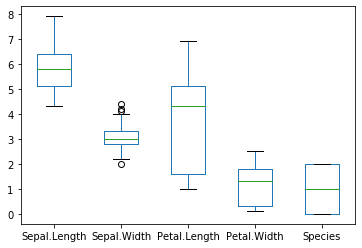

In [291]:
iris.plot(kind='box')

In [292]:
# this method doesnot worked(outliers does not removed) so we are doing quantile capping

# quantile capping

In [293]:
iris['Sepal.Width'].quantile(0.95)

3.8

In [294]:
iris['Sepal.Width'].quantile(0.05)

2.34

In [295]:
# the points above 95% and below 5% are considered as outliers

In [296]:
iris['Sepal.Width']=np.where(iris['Sepal.Width']<2.4,2.4,iris['Sepal.Width'])

In [297]:
iris['Sepal.Width']=np.where(iris['Sepal.Width']>3.8,3.8,iris['Sepal.Width'])

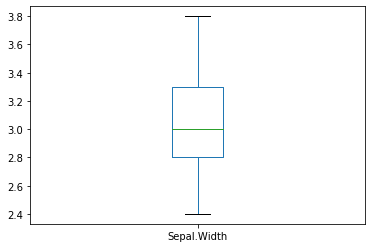

In [298]:
iris['Sepal.Width'].plot(kind='box')

In [299]:
# the outliers have be removed(imputed)

In [300]:
from sklearn.model_selection import train_test_split

In [301]:
x=iris.drop('Species',axis=1)
y=iris['Species']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=120)

# importing a library function 

In [302]:
from sklearn.tree import DecisionTreeClassifier


In [303]:
mod=DecisionTreeClassifier(max_depth=3) # we are splitting tree in to 3 default is 5 it should not exceed  5

# fitting the model to train data

In [304]:
fit=mod.fit(x_train,y_train)

# predicting using train data


In [305]:
pred1=mod.predict(x_train) # we predict the y values using train data

In [306]:
# we predict on train data and test data and we compare the we say it overfitting or underfitting
from sklearn.metrics import confusion_matrix,classification_report

In [307]:
confusion_matrix(pred1,y_train) # confusion matrix btw predicted values and actual values

array([[31,  0,  0],
       [ 0, 37,  1],
       [ 0,  2, 33]], dtype=int64)

In [308]:
# here form the confusion matrix there are 3 errors in 104 values

In [309]:
x_train.shape 

(104, 4)

# classification report 

In [310]:
print(classification_report(pred1,y_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       0.95      0.97      0.96        38
           2       0.97      0.94      0.96        35

    accuracy                           0.97       104
   macro avg       0.97      0.97      0.97       104
weighted avg       0.97      0.97      0.97       104



In [311]:
pred2=mod.predict(x_test)

In [312]:
confusion_matrix(pred2,y_test)

array([[19,  0,  0],
       [ 0, 10,  0],
       [ 0,  1, 15]], dtype=int64)

In [313]:
print(classification_report(pred2,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.91      1.00      0.95        10
           2       1.00      0.94      0.97        16

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.97        45
weighted avg       0.98      0.98      0.98        45



In [314]:
# finally it is good model

# plotting the decision tree

In [315]:
from   sklearn.tree import plot_tree

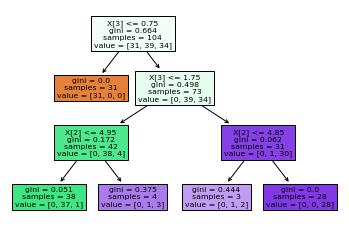

In [316]:
plot_tree(fit,filled=True);

# Random Forest

In [317]:
from sklearn.ensemble import RandomForestClassifier

In [318]:
mod1=RandomForestClassifier(n_estimators=100,criterion='entropy',random_state=10) # 100 tress will grow # impurity measure gini or entropy/


In [319]:
fit=mod1.fit(x_train,y_train)

In [320]:
pred2=fit.predict(x_train)

In [321]:
confusion_matrix(pred2,y_train)

array([[31,  0,  0],
       [ 0, 39,  0],
       [ 0,  0, 34]], dtype=int64)

In [322]:
# here there is no error

In [323]:
print(classification_report(pred2,y_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00        39
           2       1.00      1.00      1.00        34

    accuracy                           1.00       104
   macro avg       1.00      1.00      1.00       104
weighted avg       1.00      1.00      1.00       104



In [324]:
pred3=fit.predict(x_test)

In [325]:
confusion_matrix(pred3,y_test)

array([[19,  0,  0],
       [ 0, 10,  0],
       [ 0,  1, 15]], dtype=int64)

In [326]:
print(classification_report(pred3,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.91      1.00      0.95        10
           2       1.00      0.94      0.97        16

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.97        45
weighted avg       0.98      0.98      0.98        45



# logistic regression

In [327]:
%cd Desktop


[WinError 2] The system cannot find the file specified: 'Desktop'
C:\Users\Vijji\Desktop


In [328]:
data=pd.read_csv("diabetes (1).csv")

In [329]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [330]:
data.shape

(768, 9)

In [331]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


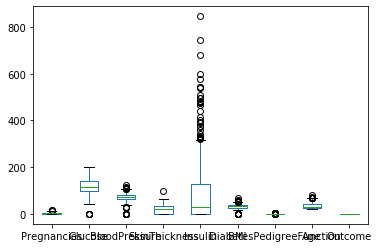

In [332]:
data.plot(kind="box")

In [333]:
y=data['Outcome']

In [334]:
x=data.drop('Outcome',axis=1)

In [335]:
# every tym we do classification we should know the count of each class

In [336]:
pd.value_counts(data.Outcome)

0    500
1    268
Name: Outcome, dtype: int64

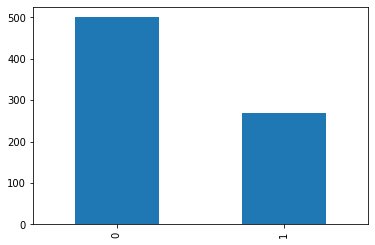

In [337]:
pd.value_counts(data.Outcome).plot(kind="bar")

# checking missing values of the data

In [338]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# checking for duplicates

In [339]:
data.duplicated().sum()

0

# checking for outliers

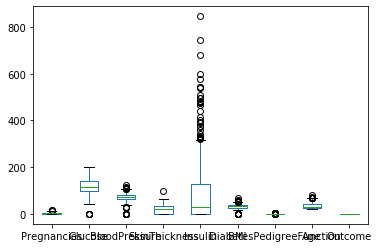

In [340]:
data.plot(kind="box")

# subplotting

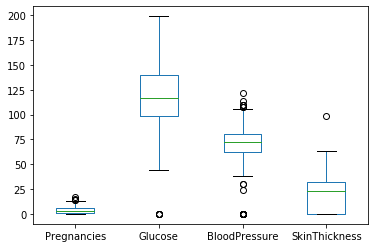

In [341]:
data.iloc[:,[0,1,2,3]].plot(kind='box')

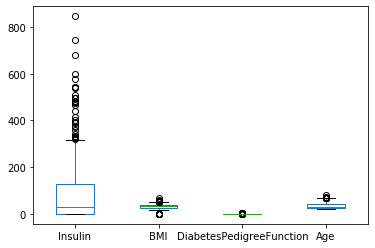

In [342]:
data.iloc[:,[4,5,6,7]].plot(kind='box')

In [343]:
# we do scaling to remove the outliers because all the columns having outliers
# min max scaling ot standard scalar

In [344]:
from sklearn.preprocessing import StandardScaler

In [345]:
scale=StandardScaler()

In [346]:
data_scale=scale.fit_transform(x);

In [347]:
data_scale

array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]])

# building logistic regression model on scaled data

In [348]:
from sklearn.linear_model import LogisticRegression

In [349]:
# train-test-split

In [350]:
from sklearn.model_selection import train_test_split

In [351]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=10)

# building logistic regression on train data

In [352]:
fit=mod.fit(x_train,y_train)

# preiction of the model on train data

In [353]:
pred1=fit.predict(x_train)

In [354]:
pred1

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,

# confusion matrix

In [355]:
from sklearn.metrics import confusion_matrix,classification_report

In [356]:
confusion_matrix(pred1,y_train)

array([[336,  95],
       [ 20,  86]], dtype=int64)

In [357]:
print(classification_report(pred1,y_train))

              precision    recall  f1-score   support

           0       0.94      0.78      0.85       431
           1       0.48      0.81      0.60       106

    accuracy                           0.79       537
   macro avg       0.71      0.80      0.73       537
weighted avg       0.85      0.79      0.80       537



In [358]:
pred2=fit.predict(x_test)

In [359]:
confusion_matrix(pred2,y_test)

array([[133,  57],
       [ 11,  30]], dtype=int64)

In [360]:
print(classification_report(pred2,y_test))

              precision    recall  f1-score   support

           0       0.92      0.70      0.80       190
           1       0.34      0.73      0.47        41

    accuracy                           0.71       231
   macro avg       0.63      0.72      0.63       231
weighted avg       0.82      0.71      0.74       231



# plotting ROC curve

In [361]:
from sklearn.metrics import plot_roc_curve

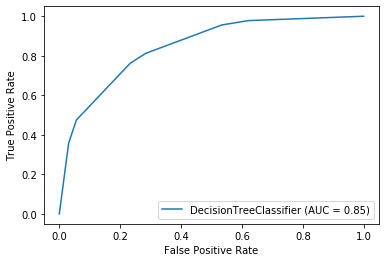

In [365]:
plot_roc_curve(fit,x_train,y_train)

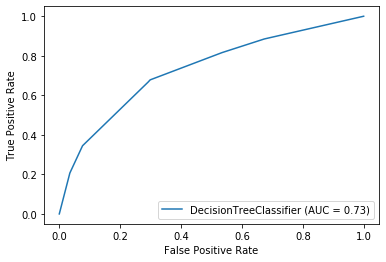

In [368]:
plot_roc_curve(fit,x_test,y_test)

In [369]:
# the result is less for test data and it is more for train data
# the model is overfitting

# conclusion: model is overfitting